In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving archive.zip to archive.zip


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [3]:
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

In [5]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

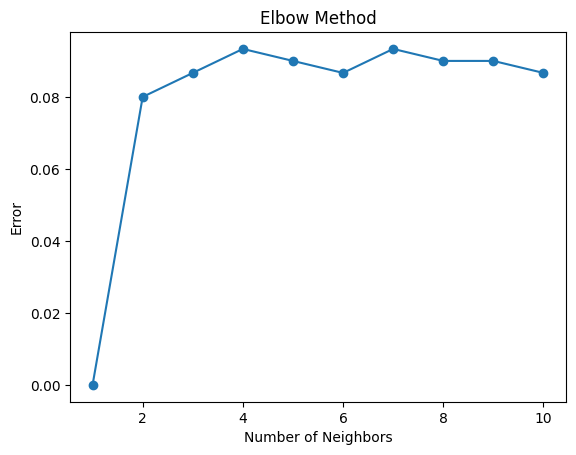

In [6]:
from sklearn.neighbors import KNeighborsClassifier

wcss = []

for i in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    wcss.append(1 - knn.score(X_train, y_train))  # proxy for error

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Neighbors')
plt.ylabel('Error')
plt.show()

In [7]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [8]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion='entropy', random_state=0)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [9]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', random_state=0)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

In [10]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score

def evaluate(name, y_test, y_pred):
    print(f"\n{name}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Accuracy:", accuracy_score(y_test, y_pred))

evaluate("KNN", y_test, y_pred_knn)
evaluate("Decision Tree", y_test, y_pred_dt)
evaluate("SVM", y_test, y_pred_svm)
evaluate("Naive Bayes", y_test, y_pred_nb)


KNN
Confusion Matrix:
 [[64  4]
 [ 3 29]]
Accuracy: 0.93

Decision Tree
Confusion Matrix:
 [[62  6]
 [ 3 29]]
Accuracy: 0.91

SVM
Confusion Matrix:
 [[64  4]
 [ 3 29]]
Accuracy: 0.93

Naive Bayes
Confusion Matrix:
 [[65  3]
 [ 7 25]]
Accuracy: 0.9


In [13]:
new_customer = np.array([[30, 87000]])
new_customer = sc.transform(new_customer)

print("KNN:", knn.predict(new_customer))
print("DT:", dt.predict(new_customer))
print("SVM:", svm.predict(new_customer))
print("NB:", nb.predict(new_customer))

KNN: [0]
DT: [0]
SVM: [0]
NB: [0]
